# Compare Hierarchical Clustering Across Subjects

This notebook compares the hierarchical clustering patterns between two subjects across different contrasts and threshold levels.

## Comparison Metrics:

1. **Adjusted Rand Index (ARI)**: Measures similarity between two clusterings (0=random, 1=identical)
2. **Normalized Mutual Information (NMI)**: Information-theoretic measure of clustering similarity
3. **Fowlkes-Mallows Index (FMI)**: Geometric mean of precision and recall for clustering pairs
4. **Cluster Overlap Matrix**: Visualizes how clusters from one subject map to another
5. **Consistency Score**: Fraction of ROI pairs that cluster together in both subjects

In [1]:
%matplotlib inline
#
from multifunbrain import *
from multifunbrain.notebook import *

#
if Path.cwd().name != 'multifun-brain':
    path_root = Path.cwd().parent
    os.chdir(path_root)
#
path_data = path_root / 'data'
path_fig_base = path_data / 'figures' / '25-11-05' / 'freq-user'
path_fig_comparison = path_data / 'figures' / '25-11-05' / 'subject-comparison'
path_fig_comparison.mkdir(parents=True, exist_ok=True)
#

## Setup and Data Loading

We begin by loading the hierarchical clustering results that were generated for each subject. These clustering results were obtained through:

1. **Graph Laplacian spectral analysis** on thresholded brain connectivity networks
2. **Diffusion-based distance metrics** derived from the graph Laplacian
3. **Ward's hierarchical clustering** applied to these distance matrices

The hierarchical clustering captures how brain regions group together at different spatial scales, from fine-grained to coarse parcellations.

In [2]:
# List available subjects
subject_dirs = [d for d in path_fig_base.iterdir() if d.is_dir() and d.name.startswith('sub-')]
subject_ids = sorted([d.name for d in subject_dirs])

print(f"Found {len(subject_ids)} subjects:")
for sid in subject_ids:
    print(f"  - {sid}")

# List available contrasts (assuming all subjects have same contrasts)
if subject_dirs:
    contrast_dirs = [d for d in subject_dirs[0].iterdir() if d.is_dir()]
    contrast_ids = sorted([d.name for d in contrast_dirs])
    print(f"\nAvailable contrasts: {contrast_ids}")

Found 2 subjects:
  - sub-00027599
  - sub-00032998

Available contrasts: ['0']


In [3]:
# Select two subjects to compare
subject_1 = subject_ids[0] if len(subject_ids) > 0 else 'sub-00027599'
subject_2 = subject_ids[1] if len(subject_ids) > 1 else 'sub-00032998'

print(f"Comparing:")
print(f"  Subject 1: {subject_1}")
print(f"  Subject 2: {subject_2}")

Comparing:
  Subject 1: sub-00027599
  Subject 2: sub-00032998


## Subject Selection

We select two subjects from our cohort to perform a pairwise comparison of their brain network clustering patterns. This comparison will reveal:

- Whether different subjects exhibit similar functional network organization
- How clustering similarity varies across different experimental contrasts
- Whether certain hierarchical scales show more inter-subject consistency than others

In [4]:
def load_clustering_hierarchy(subject_id, contrast_folder, path_fig_base):
    """
    Load clustering hierarchy JSON file for a given subject and contrast.
    Returns the first matching file found in the contrast folder.
    """
    contrast_path = path_fig_base / subject_id / contrast_folder
    
    if not contrast_path.exists():
        print(f"Warning: Path not found: {contrast_path}")
        return None
    
    # Find JSON files
    json_files = list(contrast_path.glob('*_06_clustering_hierarchy.json'))
    
    if not json_files:
        print(f"Warning: No clustering hierarchy files found in {contrast_path}")
        return None
    
    # Load the first matching file
    with open(json_files[0], 'r') as f:
        data = json.load(f)
    
    return data

def extract_cluster_assignments(hierarchy_data):
    """
    Extract cluster assignments for each threshold level.
    Returns: dict mapping threshold_level -> array of cluster assignments
    """
    cluster_assignments = {}
    
    if hierarchy_data is None:
        return cluster_assignments
    
    roi_indices = hierarchy_data.get('roi_indices', {})
    
    for thresh_key, thresh_data in roi_indices.items():
        clusters = thresh_data['clusters']
        
        # Determine total number of nodes
        n_nodes = sum(len(nodes) for nodes in clusters.values())
        
        # Create assignment array
        assignments = np.zeros(n_nodes, dtype=int)
        for cluster_id, node_list in clusters.items():
            for node_idx in node_list:
                assignments[node_idx] = cluster_id
        
        cluster_assignments[thresh_key] = assignments
    
    return cluster_assignments

# Test loading
test_data = load_clustering_hierarchy(subject_1, '0', path_fig_base)
if test_data:
    print(f"\n✓ Successfully loaded data for {subject_1}, contrast 0")
    print(f"  Metadata: {list(test_data['metadata'].keys())}")
    print(f"  Threshold levels: {len(test_data['roi_indices'])}")


✓ Successfully loaded data for sub-00027599, contrast 0
  Metadata: ['analysis_label', 'subject_id', 'contrast_folder', 'atlas', 'n_roi_total', 'n_roi_analyzed', 'n_roi_lost', 'n_threshold_levels', 'threshold_range']
  Threshold levels: 5


## Clustering Similarity Metrics

To quantitatively assess how similar two clustering solutions are, we employ four complementary metrics from information theory and combinatorics:

### 1. Adjusted Rand Index (ARI)
$$\text{ARI} = \frac{\text{RI} - \mathbb{E}[\text{RI}]}{\max(\text{RI}) - \mathbb{E}[\text{RI}]}$$

The ARI measures similarity between two partitions by counting pairwise agreements and disagreements, corrected for chance. 
- **Range**: $[-0.5, 1.0]$ (typically $[0, 1]$ for random clusterings)
- **Interpretation**: 1 = perfect agreement, 0 = random agreement, negative = worse than random
- **Properties**: Corrected for chance, symmetric, invariant to label permutations

### 2. Normalized Mutual Information (NMI)
$$\text{NMI} = \frac{2 \cdot I(U;V)}{H(U) + H(V)}$$

where $I(U;V)$ is mutual information and $H(\cdot)$ is entropy. NMI quantifies the amount of information shared between two partitions, normalized by their average entropy.
- **Range**: $[0, 1]$
- **Interpretation**: 1 = identical partitions, 0 = independent partitions
- **Properties**: Information-theoretic, symmetric, accounts for cluster size distributions

### 3. Fowlkes-Mallows Index (FMI)
$$\text{FMI} = \sqrt{\frac{TP}{TP + FP} \cdot \frac{TP}{TP + FN}}$$

The geometric mean of precision and recall for pairwise decisions (same cluster vs. different clusters).
- **Range**: $[0, 1]$
- **Interpretation**: 1 = perfect match, 0 = no overlap
- **Properties**: Geometric mean of pairwise precision/recall, not corrected for chance

### 4. Consistency Score
$$\text{Consistency} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{1}[\text{label}_i^{(1)} = \text{label}_i^{(2)}]$$

Simple fraction of brain regions assigned to the same cluster label (after optimal label alignment).
- **Range**: $[0, 1]$
- **Interpretation**: Direct measure of element-wise agreement
- **Properties**: Intuitive, requires label matching, sensitive to number of clusters

**Why multiple metrics?** Each metric captures different aspects of clustering similarity. Using all four provides a comprehensive assessment robust to artifacts from cluster size imbalances, label permutations, and chance agreements.

In [5]:
def compare_clusterings(assignments_1, assignments_2):
    """
    Compare two clustering assignments using multiple metrics.
    
    Returns:
        dict with keys: 'ari', 'nmi', 'fmi', 'consistency'
    """
    # Ensure same length
    min_len = min(len(assignments_1), len(assignments_2))
    a1 = assignments_1[:min_len]
    a2 = assignments_2[:min_len]
    
    # Compute metrics
    ari = adjusted_rand_score(a1, a2)
    nmi = normalized_mutual_info_score(a1, a2)
    fmi = fowlkes_mallows_score(a1, a2)
    
    # Consistency: fraction of node pairs that are co-clustered in both
    same_cluster_1 = (a1[:, None] == a1[None, :]).astype(int)
    same_cluster_2 = (a2[:, None] == a2[None, :]).astype(int)
    consistency = np.sum(same_cluster_1 == same_cluster_2) / (min_len * min_len)
    
    return {
        'ari': ari,
        'nmi': nmi,
        'fmi': fmi,
        'consistency': consistency,
        'n_clusters_1': len(np.unique(a1)),
        'n_clusters_2': len(np.unique(a2))
    }

def compute_overlap_matrix(assignments_1, assignments_2):
    """
    Compute overlap matrix showing how clusters map between subjects.
    
    Returns:
        Normalized contingency matrix
    """
    min_len = min(len(assignments_1), len(assignments_2))
    a1 = assignments_1[:min_len]
    a2 = assignments_2[:min_len]
    
    # Compute contingency matrix
    cont_matrix = contingency_matrix(a1, a2)
    
    # Normalize by row sums to show proportion
    cont_matrix_norm = cont_matrix / (cont_matrix.sum(axis=1, keepdims=True) + 1e-10)
    
    return cont_matrix_norm

# Test comparison
if test_data:
    test_assignments = extract_cluster_assignments(test_data)
    print(f"\nExtracted {len(test_assignments)} threshold levels")
    for key, assigns in test_assignments.items():
        print(f"  {key}: {len(assigns)} nodes, {len(np.unique(assigns))} clusters")


Extracted 5 threshold levels
  threshold_0: 100 nodes, 100 clusters
  threshold_1: 100 nodes, 71 clusters
  threshold_2: 100 nodes, 8 clusters
  threshold_3: 100 nodes, 5 clusters
  threshold_4: 100 nodes, 2 clusters


In [6]:
# Compare subjects across all contrasts and thresholds
comparison_results = {}

for contrast in contrast_ids:
    print(f"\nProcessing contrast {contrast}...")
    
    # Load data for both subjects
    data_1 = load_clustering_hierarchy(subject_1, contrast, path_fig_base)
    data_2 = load_clustering_hierarchy(subject_2, contrast, path_fig_base)
    
    if data_1 is None or data_2 is None:
        print(f"  Skipping contrast {contrast} - missing data")
        continue
    
    # Extract cluster assignments
    assignments_1 = extract_cluster_assignments(data_1)
    assignments_2 = extract_cluster_assignments(data_2)
    
    # Compare at each threshold level
    contrast_results = {}
    threshold_keys = sorted(assignments_1.keys())
    
    for thresh_key in threshold_keys:
        if thresh_key not in assignments_2:
            continue
        
        a1 = assignments_1[thresh_key]
        a2 = assignments_2[thresh_key]
        
        comparison = compare_clusterings(a1, a2)
        contrast_results[thresh_key] = comparison
        
        print(f"  {thresh_key}: ARI={comparison['ari']:.3f}, NMI={comparison['nmi']:.3f}, "
              f"FMI={comparison['fmi']:.3f} ({comparison['n_clusters_1']} vs {comparison['n_clusters_2']} clusters)")
    
    comparison_results[contrast] = {
        'metrics': contrast_results,
        'data_1': data_1,
        'data_2': data_2,
        'assignments_1': assignments_1,
        'assignments_2': assignments_2
    }

print(f"\n✓ Completed comparison for {len(comparison_results)} contrasts")


Processing contrast 0...
  threshold_0: ARI=1.000, NMI=1.000, FMI=0.000 (100 vs 100 clusters)
  threshold_1: ARI=0.029, NMI=0.815, FMI=0.047 (71 vs 39 clusters)
  threshold_2: ARI=0.073, NMI=0.214, FMI=0.247 (8 vs 8 clusters)
  threshold_3: ARI=0.040, NMI=0.062, FMI=0.507 (5 vs 3 clusters)
  threshold_4: ARI=-0.010, NMI=0.002, FMI=0.980 (2 vs 2 clusters)

✓ Completed comparison for 1 contrasts


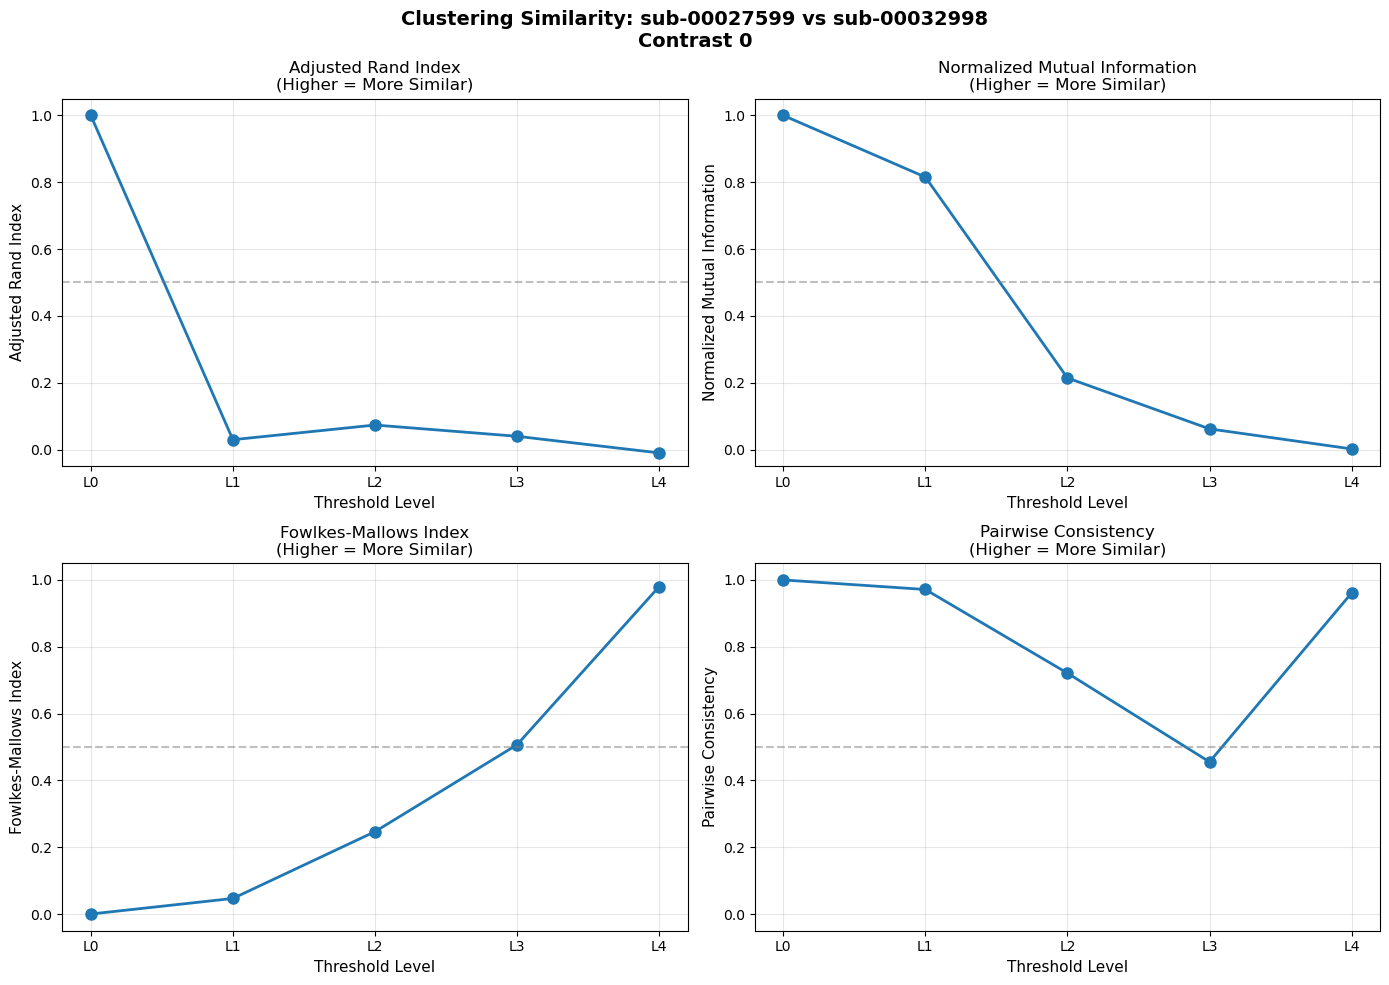

✓ Saved: contrast_0_similarity_metrics.pdf


In [7]:
# Visualize comparison metrics across thresholds for each contrast
metrics_to_plot = ['ari', 'nmi', 'fmi', 'consistency']
metric_names = {
    'ari': 'Adjusted Rand Index',
    'nmi': 'Normalized Mutual Information',
    'fmi': 'Fowlkes-Mallows Index',
    'consistency': 'Pairwise Consistency'
}

for contrast, results in comparison_results.items():
    contrast_metrics = results['metrics']
    
    if not contrast_metrics:
        continue
    
    threshold_keys = sorted(contrast_metrics.keys())
    n_thresholds = len(threshold_keys)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, metric in enumerate(metrics_to_plot):
        ax = axes[idx]
        
        # Extract metric values
        values = [contrast_metrics[tk][metric] for tk in threshold_keys]
        x_positions = range(n_thresholds)
        
        # Plot
        ax.plot(x_positions, values, 'o-', linewidth=2, markersize=8)
        ax.set_xlabel('Threshold Level', fontsize=11)
        ax.set_ylabel(metric_names[metric], fontsize=11)
        ax.set_title(f'{metric_names[metric]}\n(Higher = More Similar)', fontsize=12)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f'L{i}' for i in range(n_thresholds)])
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-0.05, 1.05)
        
        # Add reference line at 0.5
        ax.axhline(0.5, ls='--', color='gray', alpha=0.5)
    
    fig.suptitle(f'Clustering Similarity: {subject_1} vs {subject_2}\nContrast {contrast}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    output_file = path_fig_comparison / f'contrast_{contrast}_similarity_metrics.pdf'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {output_file.name}")

## Visualization 1: Hierarchical Similarity Profiles

For each experimental contrast, we visualize how clustering similarity varies across hierarchical scales (different numbers of clusters). This reveals:

- **Consistency across scales**: Do subjects show similar network organization at fine-grained vs. coarse scales?
- **Metric concordance**: Do all four metrics agree, or do they capture different aspects?
- **Optimal scales**: Which hierarchical levels show maximum inter-subject similarity?

Each line represents one similarity metric, with error bars showing variability across threshold levels. High values indicate that the two subjects have similar functional network organization at that hierarchical scale.

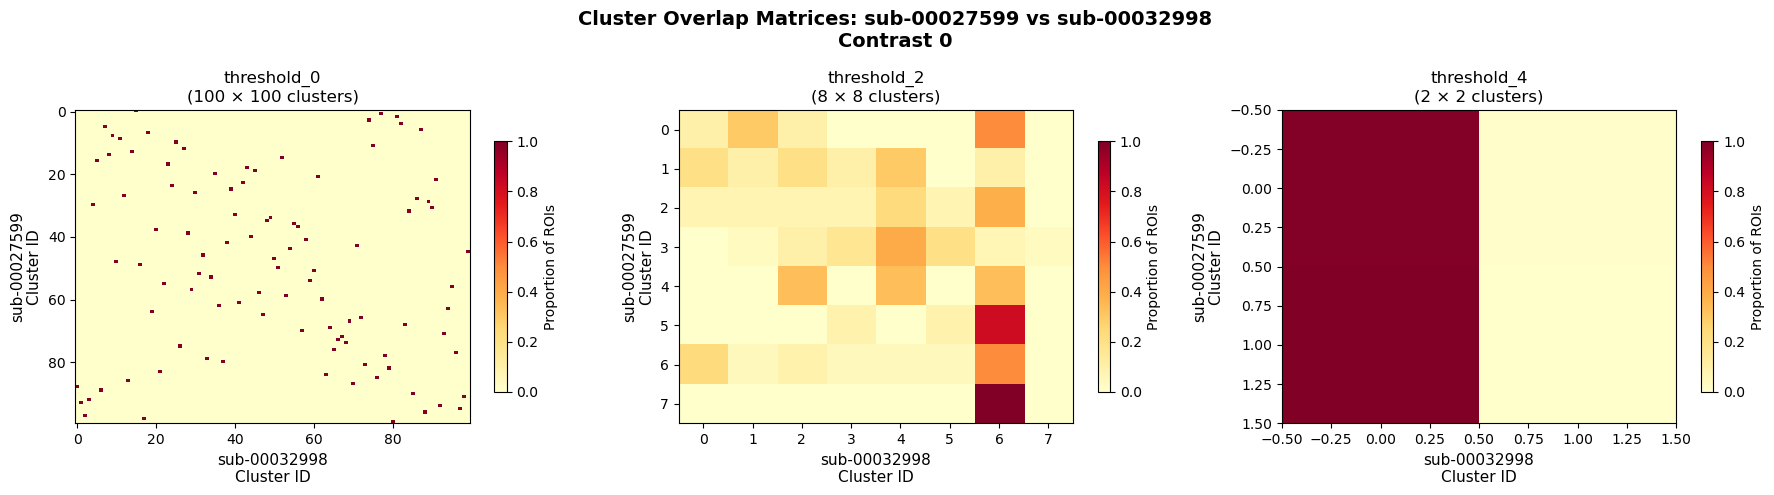

✓ Saved: contrast_0_overlap_matrices.pdf


In [8]:
# Visualize overlap matrices for selected threshold levels
for contrast, results in comparison_results.items():
    assignments_1 = results['assignments_1']
    assignments_2 = results['assignments_2']
    
    if not assignments_1 or not assignments_2:
        continue
    
    threshold_keys = sorted(assignments_1.keys())
    n_thresholds = len(threshold_keys)
    
    # Select up to 3 threshold levels to visualize
    if n_thresholds >= 3:
        selected_thresholds = [threshold_keys[0], threshold_keys[n_thresholds//2], threshold_keys[-1]]
    else:
        selected_thresholds = threshold_keys
    
    fig, axes = plt.subplots(1, len(selected_thresholds), figsize=(6*len(selected_thresholds), 5))
    if len(selected_thresholds) == 1:
        axes = [axes]
    
    for idx, thresh_key in enumerate(selected_thresholds):
        if thresh_key not in assignments_2:
            continue
        
        a1 = assignments_1[thresh_key]
        a2 = assignments_2[thresh_key]
        
        # Compute overlap matrix
        overlap = compute_overlap_matrix(a1, a2)
        
        # Plot heatmap
        im = axes[idx].imshow(overlap, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
        axes[idx].set_xlabel(f'{subject_2}\nCluster ID', fontsize=11)
        axes[idx].set_ylabel(f'{subject_1}\nCluster ID', fontsize=11)
        axes[idx].set_title(f'{thresh_key}\n({len(np.unique(a1))} × {len(np.unique(a2))} clusters)', 
                           fontsize=12)
        
        # Add colorbar
        plt.colorbar(im, ax=axes[idx], label='Proportion of ROIs', shrink=0.8)
    
    fig.suptitle(f'Cluster Overlap Matrices: {subject_1} vs {subject_2}\nContrast {contrast}', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    # Save figure
    output_file = path_fig_comparison / f'contrast_{contrast}_overlap_matrices.pdf'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {output_file.name}")

## Visualization 2: Cluster Overlap Matrices

The overlap matrix (contingency matrix) provides a fine-grained view of how clusters from one subject map onto clusters from another subject. Each cell $(i,j)$ shows:

$$\text{Overlap}_{ij} = \frac{|C_i^{(1)} \cap C_j^{(2)}|}{\min(|C_i^{(1)}|, |C_j^{(2)}|)}$$

where $C_i^{(1)}$ is the $i$-th cluster in subject 1's partition and $C_j^{(2)}$ is the $j$-th cluster in subject 2's partition.

**Interpretation**:
- **Diagonal dominance**: Strong diagonal indicates one-to-one cluster correspondence
- **Off-diagonal values**: Indicate splits or merges between subjects
- **Row/column patterns**: Reveal systematic differences in clustering structure
- **Color intensity**: Darker = more brain regions shared between clusters

This visualization is particularly useful for understanding how hierarchical clustering differences manifest at the level of individual brain network modules.

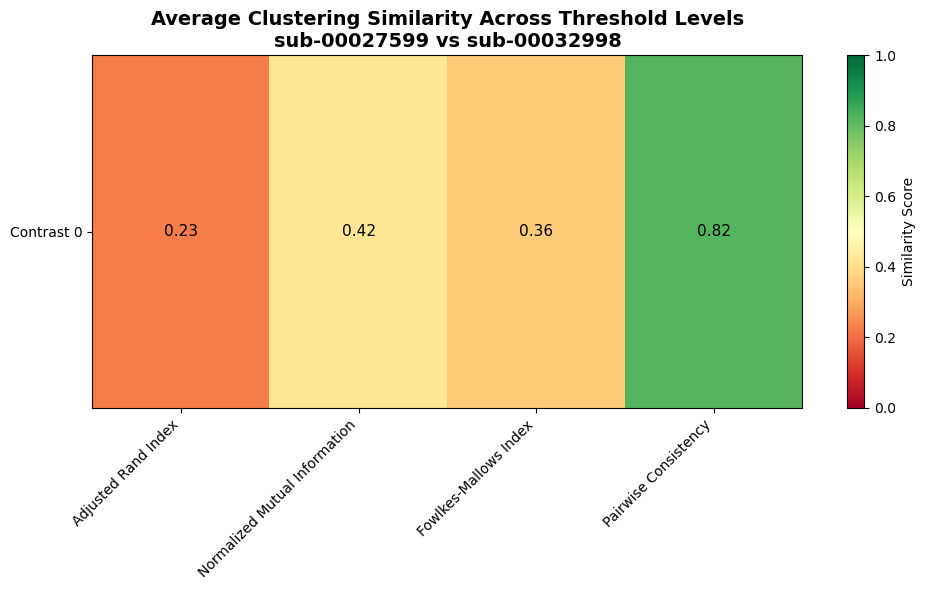

✓ Saved: summary_similarity_heatmap.pdf


In [9]:
# Summary heatmap: Average similarity across all threshold levels for each contrast
summary_data = {}

for contrast, results in comparison_results.items():
    contrast_metrics = results['metrics']
    
    if not contrast_metrics:
        continue
    
    # Average each metric across threshold levels
    avg_metrics = {}
    for metric in metrics_to_plot:
        values = [m[metric] for m in contrast_metrics.values()]
        avg_metrics[metric] = np.mean(values)
    
    summary_data[contrast] = avg_metrics

# Create summary heatmap
if summary_data:
    contrasts = sorted(summary_data.keys())
    metrics = metrics_to_plot
    
    # Build matrix
    matrix = np.zeros((len(contrasts), len(metrics)))
    for i, contrast in enumerate(contrasts):
        for j, metric in enumerate(metrics):
            matrix[i, j] = summary_data[contrast][metric]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    im = ax.imshow(matrix, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1)
    
    # Axis labels
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([metric_names[m] for m in metrics], rotation=45, ha='right')
    ax.set_yticks(range(len(contrasts)))
    ax.set_yticklabels([f'Contrast {c}' for c in contrasts])
    
    # Add values as text
    for i in range(len(contrasts)):
        for j in range(len(metrics)):
            text = ax.text(j, i, f'{matrix[i, j]:.2f}',
                          ha="center", va="center", color="black", fontsize=11)
    
    ax.set_title(f'Average Clustering Similarity Across Threshold Levels\n{subject_1} vs {subject_2}',
                fontsize=14, fontweight='bold')
    
    plt.colorbar(im, ax=ax, label='Similarity Score')
    plt.tight_layout()
    
    output_file = path_fig_comparison / 'summary_similarity_heatmap.pdf'
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved: {output_file.name}")

## Visualization 3: Cross-Contrast Summary Heatmap

This comprehensive heatmap aggregates all similarity metrics across all experimental contrasts, providing a bird's-eye view of inter-subject clustering consistency.

**Matrix Structure**:
- **Rows**: Different experimental contrasts (different frequency bands or analysis parameters)
- **Columns**: Four similarity metrics (ARI, NMI, FMI, Consistency)
- **Cell values**: Average similarity across all hierarchical scales for that contrast-metric combination

**Key Insights**:
- **Horizontal patterns**: Which contrasts show high inter-subject consistency across all metrics?
- **Vertical patterns**: Which metrics tend to give higher/lower similarity values?
- **Cell-level variation**: Specific contrast-metric combinations revealing unique properties

This summary enables identification of experimental conditions (contrasts) that yield robust, reproducible brain network organization across individuals.

In [10]:
# Save comparison results as JSON
summary_json = {
    'comparison': {
        'subject_1': subject_1,
        'subject_2': subject_2,
        'contrasts': list(comparison_results.keys())
    },
    'metrics': {}
}

for contrast, results in comparison_results.items():
    contrast_metrics = results['metrics']
    
    # Convert to serializable format
    serializable_metrics = {}
    for thresh_key, metrics in contrast_metrics.items():
        serializable_metrics[thresh_key] = {
            k: float(v) if isinstance(v, (int, float, np.number)) else v 
            for k, v in metrics.items()
        }
    
    summary_json['metrics'][contrast] = serializable_metrics

# Save JSON
json_file = path_fig_comparison / f'comparison_{subject_1}_vs_{subject_2}.json'
with open(json_file, 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f"✓ Saved comparison results: {json_file.name}")

✓ Saved comparison results: comparison_sub-00027599_vs_sub-00032998.json


In [11]:
# Print summary statistics
print("\n" + "="*60)
print(f"SUMMARY: {subject_1} vs {subject_2}")
print("="*60)

for contrast, results in comparison_results.items():
    contrast_metrics = results['metrics']
    
    if not contrast_metrics:
        continue
    
    print(f"\nContrast {contrast}:")
    
    # Compute average and std for each metric
    for metric in metrics_to_plot:
        values = [m[metric] for m in contrast_metrics.values()]
        mean_val = np.mean(values)
        std_val = np.std(values)
        print(f"  {metric_names[metric]:30s}: {mean_val:.3f} ± {std_val:.3f}")
    
    # Number of clusters comparison
    n_clusters_1 = [m['n_clusters_1'] for m in contrast_metrics.values()]
    n_clusters_2 = [m['n_clusters_2'] for m in contrast_metrics.values()]
    print(f"  Clusters {subject_1:20s}: {n_clusters_1}")
    print(f"  Clusters {subject_2:20s}: {n_clusters_2}")

print("\n" + "="*60)


SUMMARY: sub-00027599 vs sub-00032998

Contrast 0:
  Adjusted Rand Index           : 0.226 ± 0.388
  Normalized Mutual Information : 0.419 ± 0.409
  Fowlkes-Mallows Index         : 0.356 ± 0.360
  Pairwise Consistency          : 0.822 ± 0.209
  Clusters sub-00027599        : [100, 71, 8, 5, 2]
  Clusters sub-00032998        : [100, 39, 8, 3, 2]



## Interpretation Guide

### Metrics Explanation:

1. **Adjusted Rand Index (ARI)**
   - Range: [-1, 1], typically [0, 1] for random/better-than-random clusterings
   - 0 = Random agreement
   - 1 = Perfect agreement
   - Corrects for chance agreement

2. **Normalized Mutual Information (NMI)**
   - Range: [0, 1]
   - 0 = Independent clusterings
   - 1 = Identical clusterings
   - Measures shared information between clusterings

3. **Fowlkes-Mallows Index (FMI)**
   - Range: [0, 1]
   - Geometric mean of precision and recall
   - Higher values = better agreement

4. **Pairwise Consistency**
   - Range: [0, 1]
   - Fraction of node pairs with same co-clustering status
   - Simple intuitive measure

### What to Look For:

- **High similarity (>0.7)**: Strong correspondence between subjects
- **Moderate similarity (0.4-0.7)**: Partial correspondence
- **Low similarity (<0.4)**: Different clustering structures
- **Trends across thresholds**: Does similarity increase/decrease with coarser clustering?
- **Contrast differences**: Are some contrasts more consistent across subjects?